In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

class BBIEvaluatorTotal:
    """
    Classe per caricare dati BBI, calcolare RMSE totale su tutti i segmenti
    e visualizzare i fit utilizzando parametri di modello forniti dall'utente.
    """
    def __init__(self, folder_path=".", file_pattern="*.TXT"):
        """
        Parameters:
        -----------
        folder_path : str
            Percorso della cartella contenente i file di dati.
        file_pattern : str
            Pattern per trovare i file da analizzare (es. "*.TXT").
        """
        self.folder_path = folder_path
        self.file_pattern = file_pattern
        self.all_data = {}  # Dati aggregati per segmento
        self.results = {}   # Risultati (RMSE per segmento, dati predetti)
        self.total_rmse = None  # RMSE totale su tutti i segmenti

    def load_data(self, file_path):
        """Carica un singolo file di dati."""
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
            
            header_row = 0
            for i, line in enumerate(lines):
                if 'Time (s)' in line and 'Pd (nm)' in line:
                    header_row = i
                    break
            
            df = pd.read_csv(file_path, sep='\t', encoding='utf-8', 
                           skiprows=header_row, low_memory=False)
            
            df.columns = df.columns.str.strip()
            
            column_mapping = {
                'Pd (nm)': 'Pd', 'Fn (mN)': 'Fn', 'Time (s)': 'Time',
                'SegmentID': 'SegmentID', 'FnRef (mN)': 'FnRef', 'Res (ohm)': 'Res'
            }
            df = df.rename(columns=column_mapping)
            
            numeric_columns = ['Time', 'Pd', 'Fn', 'FnRef', 'SegmentID', 'Res']
            for col in numeric_columns:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            
            df = df.dropna(subset=['Pd', 'Fn', 'SegmentID'])
            return df
            
        except Exception as e:
            print(f"Errore nel caricamento di {file_path}: {e}")
            return None

    def separate_loading_unloading(self, df):
        """Separa i dati in base ai segmenti."""
        segments = {}
        if 'SegmentID' in df.columns:
            segment_names = {
                1: 'loading', 2: 'hold1', 3: 'unloading',
                4: 'hold2', 5: 'unload_light'
            }
            for seg_id, seg_name in segment_names.items():
                seg_data = df[df['SegmentID'] == seg_id].copy()
                if len(seg_data) > 0:
                    cleaned = seg_data[(seg_data['Pd'] >= 0) & (seg_data['Fn'] >= -0.001)].copy()
                    if len(cleaned) > 0:
                        segments[seg_name] = cleaned
        return segments

    def collect_all_data(self):
        """Raccoglie e aggrega i dati da tutti i file."""
        full_pattern = os.path.join(self.folder_path, self.file_pattern)
        files = glob.glob(full_pattern)
        
        if not files:
            print(f"Nessun file trovato nella cartella con il pattern specificato: {self.folder_path}")
            return

        print(f"Trovati {len(files)} file. Inizio raccolta dati...")
        
        self.all_data = {
            'loading': {'h': [], 'F': []}, 'hold1': {'h': [], 'F': []},
            'unloading': {'h': [], 'F': []}, 'hold2': {'h': [], 'F': []},
            'unload_light': {'h': [], 'F': []}
        }
        
        for file_path in files:
            df = self.load_data(file_path)
            if df is not None:
                segments = self.separate_loading_unloading(df)
                for seg_name, seg_data in segments.items():
                    if seg_name in self.all_data and len(seg_data) > 0:
                        self.all_data[seg_name]['h'].extend(seg_data['Pd'].values)
                        self.all_data[seg_name]['F'].extend(seg_data['Fn'].values)
        
        for seg_name in self.all_data:
            if self.all_data[seg_name]['h']:
                self.all_data[seg_name]['h'] = np.array(self.all_data[seg_name]['h'])
                self.all_data[seg_name]['F'] = np.array(self.all_data[seg_name]['F'])
                print(f"Segmento {seg_name}: {len(self.all_data[seg_name]['h'])} punti totali")
            else:
                print(f"Segmento {seg_name}: nessun dato")
    
    def model_function_powerlaw(self, h, params):
        """Modello power law: F = a * (h - h0)^m"""
        a, h0, m = params
        h_eff = np.maximum(h - h0, 1e-10) # Evita errori con basi negative
        return a * (h_eff ** m)

    def model_function_constant(self, h, params):
        """Modello costante: F = c"""
        c = params[0]
        return np.full_like(h, c)

    def evaluate_with_params(self, params_dict):
        """
        Calcola RMSE totale e per segmento usando parametri esterni.
        """
        if not self.all_data:
            print("Dati non caricati. Eseguire prima collect_all_data().")
            return
        
        print("\n=== VALUTAZIONE CON PARAMETRI FORNITI ===")
        self.results = {}
        
        # Liste per raccogliere tutti i valori sperimentali e predetti
        all_F_orig = []
        all_F_pred = []
        all_h_orig = []
        
        # Calcolo per ogni segmento
        for seg_name, params in params_dict.items():
            if seg_name not in self.all_data or len(self.all_data[seg_name]['h']) == 0:
                print(f"✗ Segmento {seg_name}: nessun dato sperimentale trovato, impossibile valutare.")
                continue

            h_orig = self.all_data[seg_name]['h']
            F_orig = self.all_data[seg_name]['F']
            
            result_dict = {'success': True, 'h_pred': h_orig, 'n_points': len(h_orig)}

            # Determina il modello e calcola F_pred
            if 'm' in params:  # Modello Power Law
                model_params = [params['a'], params['h0'], params['m']]
                F_pred = self.model_function_powerlaw(h_orig, model_params)
                result_dict.update({
                    'model_type': 'powerlaw',
                    'a': params['a'], 'h0': params['h0'], 'm': params['m']
                })
            else:  # Modello Costante
                model_params = [params['c']]
                F_pred = self.model_function_constant(h_orig, model_params)
                result_dict.update({
                    'model_type': 'constant',
                    'c': params['c']
                })
            
            # Calcolo RMSE per il singolo segmento
            rmse_segment = np.sqrt(np.mean((F_orig - F_pred)**2))
            result_dict['rmse'] = rmse_segment
            result_dict['F_pred'] = F_pred
            
            self.results[seg_name] = result_dict
            
            # Aggiungi ai dati totali
            all_F_orig.extend(F_orig)
            all_F_pred.extend(F_pred)
            all_h_orig.extend(h_orig)
            
            print(f"✓ Segmento {seg_name}: RMSE = {rmse_segment:.6f} ({len(h_orig)} punti)")
        
        # Calcolo RMSE totale
        if all_F_orig and all_F_pred:
            all_F_orig = np.array(all_F_orig)
            all_F_pred = np.array(all_F_pred)
            self.total_rmse = np.sqrt(np.mean((all_F_orig - all_F_pred)**2))
            
            total_points = len(all_F_orig)
            print(f"\n🎯 RMSE TOTALE: {self.total_rmse:.6f} (su {total_points} punti totali)")
            
            # Statistiche aggiuntive sui residui
            residuals = all_F_orig - all_F_pred
            print(f"📊 Residui - Media: {np.mean(residuals):.6f}, Std: {np.std(residuals):.6f}")
        else:
            print("❌ Nessun dato valido trovato per il calcolo dell'RMSE totale.")

    def get_total_rmse(self):
        """Restituisce l'RMSE totale calcolato."""
        return self.total_rmse

    def get_segment_rmse(self):
        """Restituisce un dizionario con gli RMSE per ogni segmento."""
        return {seg: result['rmse'] for seg, result in self.results.items() if 'rmse' in result}

    def plot_results(self, user_ranges=None, output_folder=r"C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2"):
        """Visualizza e salva solo il grafico continuo finale."""
        if not self.results:
            print("Nessun risultato da visualizzare. Eseguire prima evaluate_with_params().")
            return
        
        Path(output_folder).mkdir(parents=True, exist_ok=True)
        
        # Genera solo il grafico continuo
        self.plot_continuous_results(user_ranges, output_folder)

    def _calculate_segment_transitions(self):
        """Calcola automaticamente i punti di transizione tra i segmenti basandosi sui parametri."""
        if not self.results:
            return {}
        
        transitions = {}
        
        # Ordine logico dei segmenti nel ciclo
        segment_order = ['loading', 'hold1', 'unloading', 'hold2', 'unload_light']
        
        for seg_name, result in self.results.items():
            if seg_name not in segment_order:
                continue
                
            if result['model_type'] == 'powerlaw':
                a, h0, m = result['a'], result['h0'], result['m']
                
                if seg_name == 'loading':
                    # Loading: da h0 fino al punto dove incontra hold1
                    h_start = h0
                    if 'hold1' in self.results:
                        c1 = self.results['hold1']['c']
                        h_end = h0 + (c1 / a) ** (1/m)
                    else:
                        # Se non c'è hold1, usa il range dei dati
                        h_end = np.max(self.all_data[seg_name]['h'])
                    
                elif seg_name == 'unloading':
                    # Unloading: dal punto hold1 al punto hold2
                    if 'hold1' in self.results and 'hold2' in self.results:
                        c1 = self.results['hold1']['c']
                        c2 = self.results['hold2']['c']
                        h_start = h0 + (c1 / a) ** (1/m)
                        h_end = h0 + (c2 / a) ** (1/m)
                    else:
                        # Fallback sui dati
                        h_start = np.min(self.all_data[seg_name]['h'])
                        h_end = np.max(self.all_data[seg_name]['h'])
                
                elif seg_name == 'unload_light':
                    # Final unloading: dal punto hold2 fino a h0 (F=0)
                    if 'hold2' in self.results:
                        c2 = self.results['hold2']['c']
                        h_start = h0 + (c2 / a) ** (1/m)
                    else:
                        h_start = np.max(self.all_data[seg_name]['h'])
                    h_end = h0  # Fino a F=0
                    
                else:
                    # Altri segmenti power law - usa range dati
                    h_start = np.min(self.all_data[seg_name]['h'])
                    h_end = np.max(self.all_data[seg_name]['h'])
                    
            else:  # Modello costante (hold1, hold2)
                c = result['c']
                
                if seg_name == 'hold1':
                    # Hold1: tra fine loading e inizio unloading
                    if 'loading' in self.results:
                        loading_result = self.results['loading']
                        a1, h0_1, m1 = loading_result['a'], loading_result['h0'], loading_result['m']
                        h_start = h0_1 + (c / a1) ** (1/m1)
                    else:
                        h_start = np.min(self.all_data[seg_name]['h'])
                    
                    if 'unloading' in self.results:
                        unloading_result = self.results['unloading']
                        a2, h0_2, m2 = unloading_result['a'], unloading_result['h0'], unloading_result['m']
                        h_end = h0_2 + (c / a2) ** (1/m2)
                    else:
                        h_end = np.max(self.all_data[seg_name]['h'])
                
                elif seg_name == 'hold2':
                    # Hold2: tra fine unloading e inizio final unloading
                    if 'unloading' in self.results:
                        unloading_result = self.results['unloading']
                        a2, h0_2, m2 = unloading_result['a'], unloading_result['h0'], unloading_result['m']
                        h_start = h0_2 + (c / a2) ** (1/m2)
                    else:
                        h_start = np.min(self.all_data[seg_name]['h'])
                    
                    if 'unload_light' in self.results:
                        final_result = self.results['unload_light']
                        a3, h0_3, m3 = final_result['a'], final_result['h0'], final_result['m']
                        h_end = h0_3 + (c / a3) ** (1/m3)
                    else:
                        h_end = np.max(self.all_data[seg_name]['h'])
                
                else:
                    # Altri segmenti costanti - usa range dati
                    h_start = np.min(self.all_data[seg_name]['h'])
                    h_end = np.max(self.all_data[seg_name]['h'])
            
            transitions[seg_name] = {'h_min': h_start, 'h_max': h_end}
            
        return transitions

    def plot_continuous_results(self, user_ranges=None, output_folder=r"C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2"):
        """Visualizza i risultati del fit continuo con dati sperimentali e RMSE totale."""
        if not self.results:
            return
    
        fig, ax = plt.subplots(figsize=(14, 10))
        colors = {'loading': 'blue', 'hold1': 'green', 'unloading': 'red', 'hold2': 'orange', 'unload_light': 'purple'}

        # Prima plotta i dati sperimentali per ogni segmento
        for seg_name in self.results.keys():
            if seg_name in self.all_data:
                h_data, F_data = self.all_data[seg_name]['h'], self.all_data[seg_name]['F']
                if len(h_data) > 5000:
                    indices = np.random.choice(len(h_data), 5000, replace=False)
                    h_sample, F_sample = h_data[indices], F_data[indices]
                else:
                    h_sample, F_sample = h_data, F_data
                ax.scatter(F_sample, h_sample, alpha=0.3, s=1, color=colors.get(seg_name, 'gray'), 
                          label=f'{seg_name} (dati)')

        # Calcola automaticamente le transizioni tra segmenti
        if user_ranges is None:
            transitions = self._calculate_segment_transitions()
            print("📊 Transizioni calcolate automaticamente:")
            for seg, trans in transitions.items():
                print(f"  {seg}: h da {trans['h_min']:.3f} a {trans['h_max']:.3f}")
        else:
            transitions = user_ranges
            
        # Poi plotta i modelli nel loro range specifico
        for seg_name, result in self.results.items():
            if seg_name not in transitions: 
                continue
            
            h_min, h_max = transitions[seg_name]['h_min'], transitions[seg_name]['h_max']
            
            if result['model_type'] == 'powerlaw':
                h_smooth = np.linspace(h_min, h_max, 200)
                F_smooth = self.model_function_powerlaw(h_smooth, [result['a'], result['h0'], result['m']])
                ax.plot(F_smooth, h_smooth, '-', linewidth=3, color=colors.get(seg_name, 'gray'), 
                       label=f'{seg_name} (modello)')
            elif result['model_type'] == 'constant':
                h_line = np.array([h_min, h_max])
                F_line = self.model_function_constant(h_line, [result['c']])
                ax.plot(F_line, h_line, '-', linewidth=3, color=colors.get(seg_name, 'gray'), 
                       label=f'{seg_name} (modello)')

        # Titolo con RMSE totale
        title = 'Dati Sperimentali e Modelli Teorici'
        if self.total_rmse is not None:
            title += f'\nRMSE Totale: {self.total_rmse:.6f}'
        
        ax.set_xlabel('Forza Fn (mN)', fontsize=14)
        ax.set_ylabel('Profondità Pd (nm)', fontsize=14)
        ax.set_title(title, fontsize=16)
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=10, loc='lower right')
        plt.tight_layout()
        
        output_path = Path(output_folder) / "grafico_continuo_total_rmse.png"
        plt.savefig(output_path, dpi=300)
        print(f"✅ Grafico continuo salvato in: {output_path}")
        plt.show()

    def print_summary(self):
        """Stampa un riassunto dei risultati."""
        if not self.results:
            print("Nessun risultato disponibile.")
            return
        
        print("\n" + "="*60)
        print("RIASSUNTO RISULTATI")
        print("="*60)
        
        total_points = sum(result['n_points'] for result in self.results.values())
        print(f"Punti totali analizzati: {total_points}")
        
        if self.total_rmse is not None:
            print(f"RMSE TOTALE: {self.total_rmse:.6f}")
        
        print("\nRMSE per segmento:")
        for seg_name, result in self.results.items():
            print(f"  {seg_name:12}: RMSE = {result['rmse']:.6f} ({result['n_points']} punti)")
        
        print("="*60)

Trovati 49 file. Inizio raccolta dati...
Segmento loading: 4894 punti totali
Segmento hold1: 3923 punti totali
Segmento unloading: 4412 punti totali
Segmento hold2: 29405 punti totali
Segmento unload_light: 490 punti totali

=== VALUTAZIONE CON PARAMETRI FORNITI ===
✓ Segmento loading: RMSE = 0.766010 (4894 punti)
✓ Segmento hold1: RMSE = 0.202560 (3923 punti)
✓ Segmento unloading: RMSE = 0.469741 (4412 punti)
✓ Segmento hold2: RMSE = 0.029546 (29405 punti)
✓ Segmento unload_light: RMSE = 1.652041 (490 punti)

🎯 RMSE TOTALE: 0.352853 (su 43124 punti totali)
📊 Residui - Media: -0.040919, Std: 0.350472
📊 Transizioni calcolate automaticamente:
  loading: h da 0.000 a 265.196
  hold1: h da 265.196 a 286.419
  unloading: h da 286.419 a 168.693
  hold2: h da 168.693 a 142.178
  unload_light: h da 142.178 a 127.564
✅ Grafico continuo salvato in: C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2\grafico_continuo_total_rmse.png


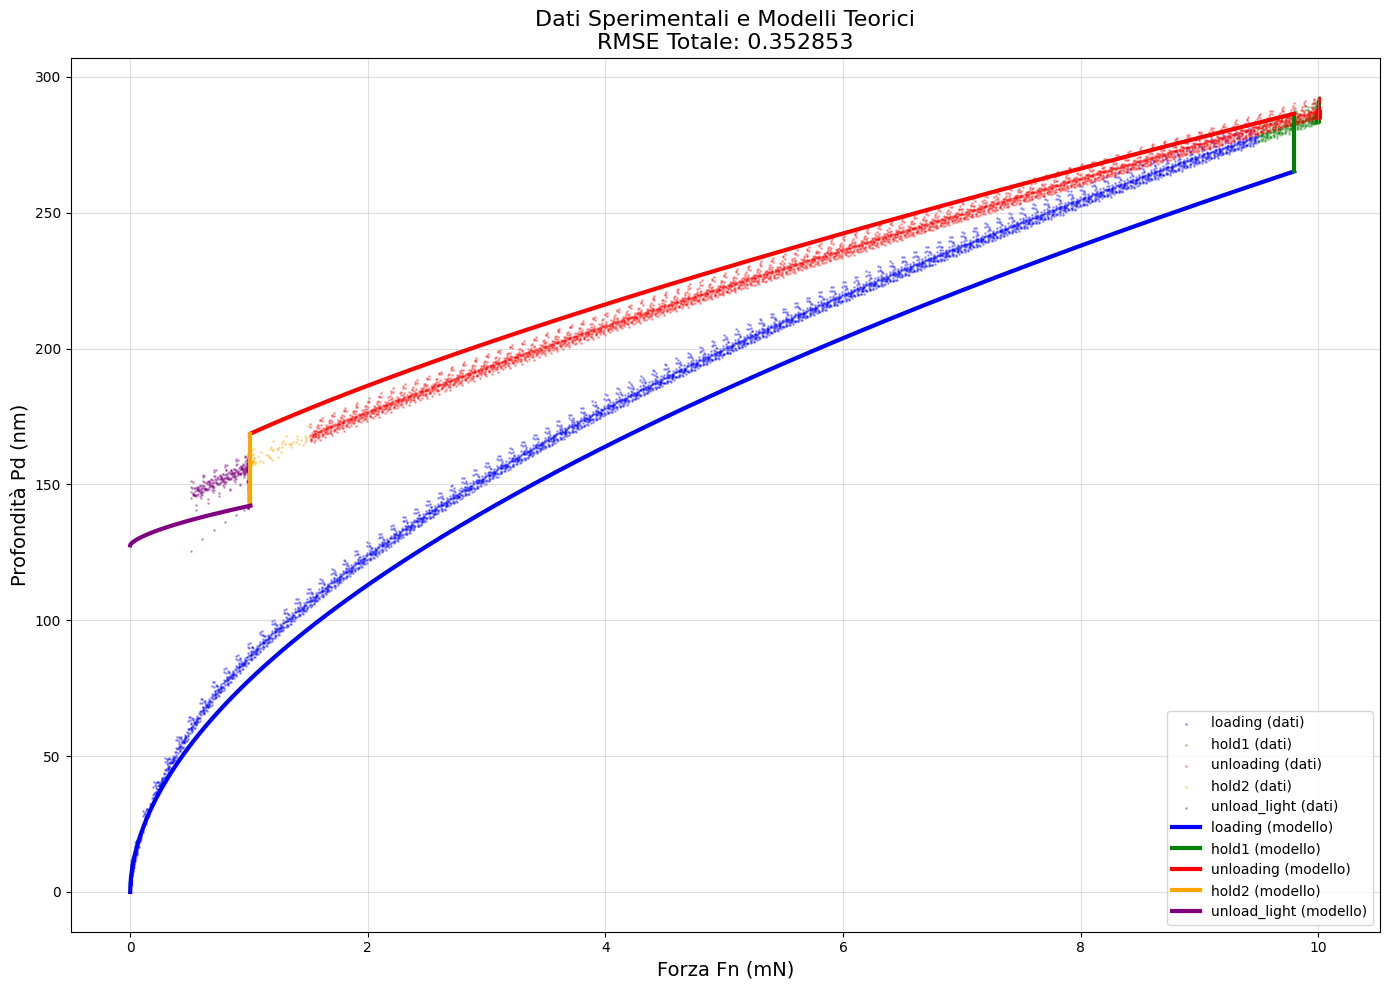


Processo completato.


In [24]:
# =======================================================================
# --- INIZIO SCRIPT PRINCIPALE ---
# =======================================================================
if __name__ == "__main__":

    # --- INPUT UTENTE ---
    # 1. Inserisci il percorso COMPLETO della cartella con i file .TXT
    # Esempio Windows: r"C:\Utenti\TuoNome\Desktop\DatiBBI"
    # Esempio Mac/Linux: "/home/TuoNome/documenti/DatiBBI"
    folder_path = r"C:\Users\geard\OneDrive\Download\Tesi\dati_ts\dataset_2"

    # 2. Inserisci i parametri PRE-CALCOLATI per ogni segmento del modello
    #    - Per 'loading', 'unloading', 'unload_light': usa 'a', 'h0', 'm'
    #    - Per 'hold1', 'hold2': usa 'c'
    predefined_params = {
        'loading': {'a': 0.0003, 'h0': 0.0, 'm': 1.8625},
        'hold1': {'c': 9.7952},
        'unloading': {'a': 0.0119, 'h0': 141.7935, 'm': 1.3496},
        'hold2': {'c': 1.0119},
        'unload_light': {'a': 0.0173, 'h0': 127.5637, 'm': 1.5171}
    }


    # 3. (Opzionale) Definisci i range di profondità (h) per il grafico "continuo".
    #    Se non vuoi usare range specifici, imposta user_ranges = None
    user_ranges = None
    
    # --- FINE INPUT UTENTE ---

    # Crea un'istanza della classe
    evaluator = BBIEvaluatorTotal(
        folder_path=folder_path,
        file_pattern="*.TXT"  # Cerca tutti i file che finiscono in .TXT
    )

    # 1. Carica e aggrega tutti i dati dalla cartella specificata
    evaluator.collect_all_data()

   

    # 2. Valuta i dati con i parametri forniti, calcola RMSE
    evaluator.evaluate_with_params(predefined_params)

    # 3. Genera e mostra i grafici (individuali e continui)
    #    I grafici verranno salvati in una sottocartella chiamata "output_plots"
    evaluator.plot_results()

    print("\nProcesso completato.")